### __*MODULE 8 CLASSIFICATION: LDA, QDQ and kNN*__

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
%cd /content/drive/MyDrive/Codes_Module08

/content/drive/MyDrive/Codes_Module08


In [13]:
df = pd.read_csv('Default.csv')
df.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


# Create functions to preprocess the data, and train and evaluate the model

In [14]:
def prepare_data():
    # Read the CSV file
    data = pd.read_csv('Default.csv')

    # Convert categorical variables to numeric
    le = LabelEncoder()
    data['default_binary'] = le.fit_transform(data['default'])
    data['student_binary'] = le.fit_transform(data['student'])

    # Prepare features and target
    X = data[['balance', 'income', 'student_binary']]
    y = data['default_binary']

    # Scale the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, y
# Train and evaluate models
def train_evaluate_models(X, y):
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize models
    lda = LinearDiscriminantAnalysis()
    qda = QuadraticDiscriminantAnalysis()
    knn = KNeighborsClassifier(n_neighbors=5)

    models = {
        'LDA': lda,
        'QDA': qda,
        'kNN': knn
    }

    # Train and evaluate each model
    results = {}
    for name, model in models.items():
        # Train model
        model.fit(X_train, y_train)

        # Make predictions
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate metrics
        results[name] = {
            'model': model,
            'y_test': y_test,
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba
        }

        # Print results
        print(f"\n{name} Results:")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))

        # Calculate cross-validation scores
        cv_scores = cross_val_score(model, X, y, cv=5)
        print(f"\nCross-validation scores: {cv_scores}")
        print(f"Average CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

    return results

# Plot ROC curves
def plot_roc_curves(results):
    plt.figure(figsize=(10, 6))

    for name, result in results.items():
        fpr, tpr, _ = roc_curve(result['y_test'], result['y_pred_proba'])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves')
    plt.legend(loc="lower right")
    plt.show()

# Plot confusion matrices
def plot_confusion_matrices(results):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for (name, result), ax in zip(results.items(), axes):
        cm = confusion_matrix(result['y_test'], result['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
        ax.set_title(f'{name} Confusion Matrix')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

    plt.tight_layout()
    plt.show()



# Call all the functions to see the results


LDA Results:

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1931
           1       0.65      0.16      0.26        69

    accuracy                           0.97      2000
   macro avg       0.81      0.58      0.62      2000
weighted avg       0.96      0.97      0.96      2000


Cross-validation scores: [0.9735 0.971  0.971  0.972  0.974 ]
Average CV score: 0.9723 (+/- 0.0025)

QDA Results:

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1931
           1       0.59      0.19      0.29        69

    accuracy                           0.97      2000
   macro avg       0.78      0.59      0.63      2000
weighted avg       0.96      0.97      0.96      2000


Cross-validation scores: [0.973  0.971  0.971  0.9725 0.9755]
Average CV score: 0.9726 (+/- 0.0033)

kNN Results:

Classification Report:
              precision    rec

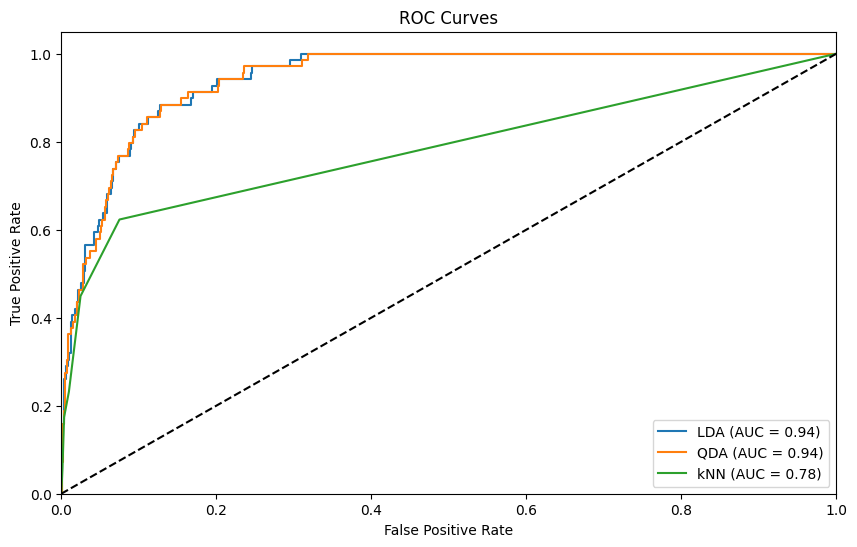

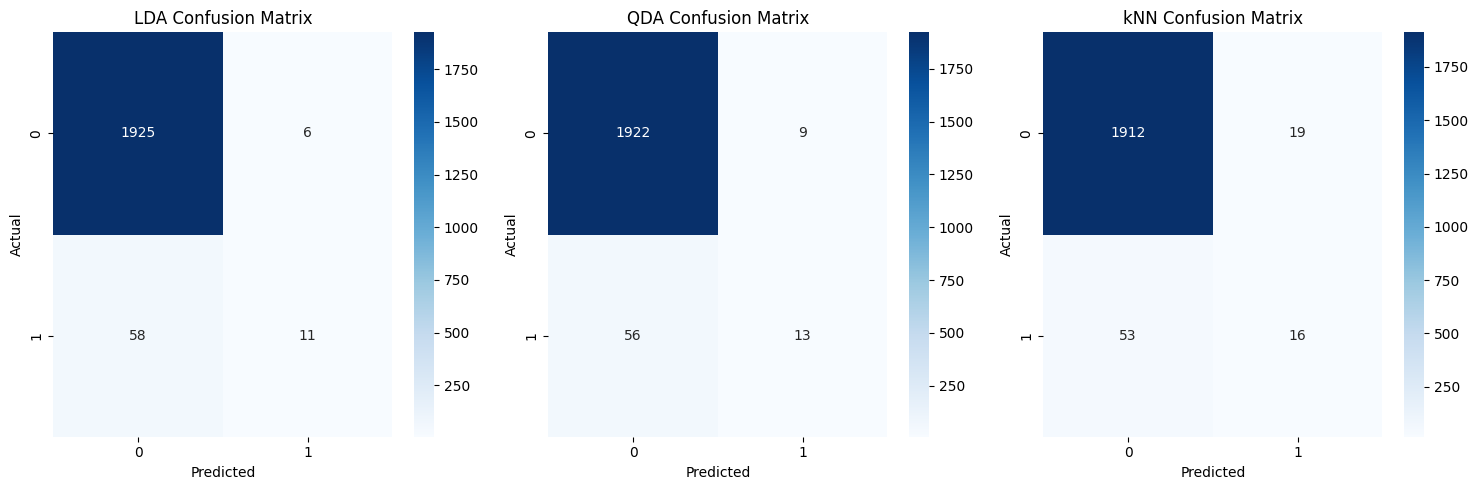


Model Comparison:
     Accuracy   ROC AUC
LDA    0.9680  0.943387
QDA    0.9675  0.942742
kNN    0.9640  0.784249


In [15]:
# Evaluation
X, y = prepare_data()
results = train_evaluate_models(X, y)
plot_roc_curves(results)
plot_confusion_matrices(results)

# Compare model performances
model_comparison = pd.DataFrame({
    name: {
        'Accuracy': (result['y_pred'] == result['y_test']).mean(),
        'ROC AUC': auc(
            *roc_curve(result['y_test'], result['y_pred_proba'])[:2]
        )
    }
    for name, result in results.items()
}).T

print("\nModel Comparison:")
print(model_comparison)

# Observe the decision Boundaries

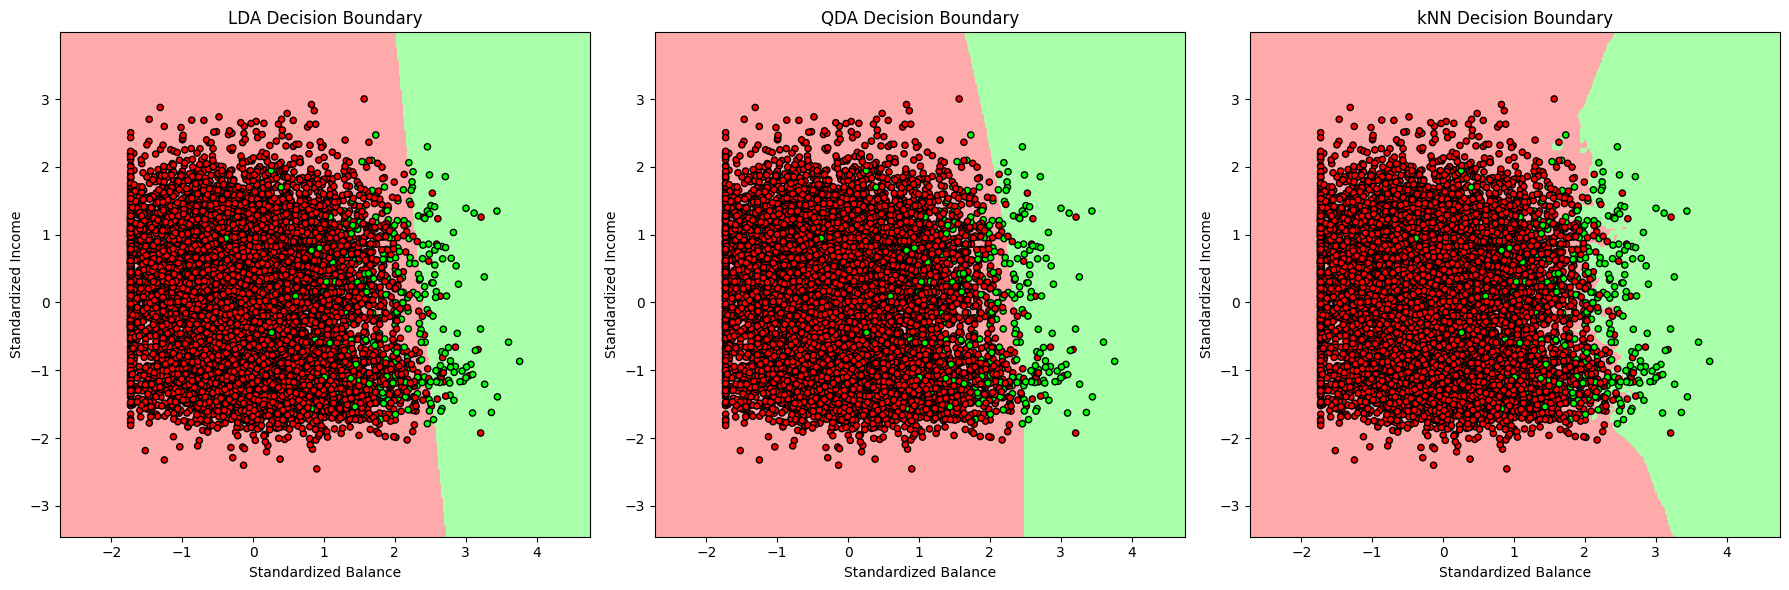

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_decision_boundaries(X, y, models, feature_names=['Balance', 'Income']):
    # Reduce to 2D for visualization (using first two features)
    X_2d = X[:, :2]

    # Create mesh grid
    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                        np.arange(y_min, y_max, 0.02))

    # Create color maps
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00'])

    # Plot each model
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for idx, (name, model) in enumerate(models.items()):
        # Train model on 2D data
        model.fit(X_2d, y)

        # Plot decision boundary
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        axes[idx].contourf(xx, yy, Z, cmap=cmap_light)
        axes[idx].scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap=cmap_bold,
                         edgecolors='black', s=20)

        axes[idx].set_title(f'{name} Decision Boundary')
        axes[idx].set_xlabel(feature_names[0])
        axes[idx].set_ylabel(feature_names[1])
        axes[idx].set_xlim(xx.min(), xx.max())
        axes[idx].set_ylim(yy.min(), yy.max())

    plt.tight_layout()
    plt.show()

# Get the data and models
X, y = prepare_data()
models = {
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
    'kNN': KNeighborsClassifier(n_neighbors=5)
}

# Plot decision boundaries
plot_decision_boundaries(X, y, models, ['Standardized Balance', 'Standardized Income'])